In [3]:
# Import Libraries
import pandas as pd
import numpy as np
import random
from faker import Faker
from datetime import datetime, timedelta

# For reproducible results
np.random.seed(42)
random.seed(42)

fake = Faker("en_IN")

In [4]:
# Define Project Settings
NUM_USERS = 1200

PERSONAS = [
    "Student",
    "Working Professional",
    "Family User",
    "Budget Conscious",
    "Frequent Traveler",
    "High Spender"
]

CITIES = [
    "Delhi",
    "Mumbai",
    "Bengaluru",
    "Noida",
    "Gurgaon",
    "Chandigarh",
    "Pune",
    "Hyderabad",
    "Ludhiana",
    "Kolkata",
    "Jaipur",
    "Ahmedabad"
]

DEVICES = ["Android", "iOS"]

BANKS = [
    "HDFC Bank",
    "ICICI Bank",
    "State Bank of India",
    "Axis Bank",
    "Kotak Mahindra Bank"
]

In [5]:
# Persona Distribution
PERSONA_PROBS = {
    "Student": 0.20,
    "Working Professional": 0.30,
    "Family User": 0.18,
    "Budget Conscious": 0.12,
    "Frequent Traveler": 0.10,
    "High Spender": 0.10
}

In [6]:
sum(PERSONA_PROBS.values())

1.0

In [7]:
# Persona-wise Age Groups
AGE_GROUPS = {
    "Student": ["18-20", "21-24"],
    "Working Professional": ["22-24", "25-34", "35-44"],
    "Family User": ["30-39", "40-49", "50-59"],
    "Budget Conscious": ["25-34", "35-44", "45-54"],
    "Frequent Traveler": ["25-34", "35-44", "45-54"],
    "High Spender": ["30-39", "40-49", "50-59"]
}

In [8]:
# Generate 1,200 Users
users = []

persona_names = list(PERSONA_PROBS.keys())
persona_weights = list(PERSONA_PROBS.values())

for i in range(1, NUM_USERS + 1):

    user_id = f"U{i:04d}"

    persona = random.choices(
        persona_names,
        weights=persona_weights,
        k=1
    )[0]

    age_group = random.choice(AGE_GROUPS[persona])

    city = random.choice(CITIES)

    device = random.choices(
        DEVICES,
        weights=[0.82, 0.18],
        k=1
    )[0]

    bank = random.choice(BANKS)

    join_date = fake.date_between(
        start_date="-3y",
        end_date="-30d"
    )

    users.append([
        user_id,
        persona,
        age_group,
        city,
        device,
        bank,
        join_date
    ])

In [9]:
# Create DataFrame
users_df = pd.DataFrame(
    users,
    columns=[
        "User_ID",
        "User_Persona",
        "Age_Group",
        "City",
        "Device_Type",
        "Bank",
        "Join_Date"
    ]
)

users_df.head()

,User_ID,User_Persona,Age_Group,City,Device_Type,Bank,Join_Date
0,U0001,Family User,30-39,Ahmedabad,Android,ICICI Bank,2023-10-06
1,U0002,Student,18-20,Jaipur,Android,Kotak Mahindra Bank,2023-09-16
2,U0003,Student,21-24,Delhi,Android,ICICI Bank,2024-11-09
3,U0004,Working Professional,35-44,Delhi,Android,Kotak Mahindra Bank,2023-11-26
4,U0005,Working Professional,25-34,Kolkata,Android,HDFC Bank,2024-07-12


In [10]:
# Check Persona Distribution
users_df["User_Persona"].value_counts()

,count
User_Persona,
Working Professional,367
Family User,234
Student,232
Budget Conscious,141
High Spender,118
Frequent Traveler,108


In [11]:
# Save users.csv
users_df.to_csv("users.csv", index=False)

print("users.csv created successfully!")
print("Total Users:", len(users_df))

users.csv created successfully!
Total Users: 1200


In [12]:
# download users.csv
from google.colab import files

files.download("users.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
# Generate UPI Transactions
# Define Categories and Merchants
CATEGORY_MERCHANTS = {
    "Food & Dining": [
        "Swiggy", "Zomato", "McDonald's", "Domino's", "Local Restaurant"
    ],

    "Grocery": [
        "Blinkit", "Zepto", "BigBasket", "DMart", "Local Grocery Store"
    ],

    "Shopping": [
        "Amazon", "Flipkart", "Myntra", "Meesho", "Reliance Retail"
    ],

    "Transportation": [
        "Uber", "Ola", "Rapido", "Delhi Metro", "Local Transport"
    ],

    "Travel": [
        "IRCTC", "MakeMyTrip", "Goibibo", "IndiGo", "Air India"
    ],

    "Healthcare": [
        "Apollo Pharmacy", "PharmEasy", "Tata 1mg", "Local Hospital"
    ],

    "Entertainment": [
        "BookMyShow", "Netflix", "Spotify", "Gaming"
    ],

    "Bills & Utilities": [
        "Electricity Bill", "Water Bill", "Gas Bill", "Broadband"
    ],

    "Mobile Recharge": [
        "Jio", "Airtel", "Vi", "BSNL"
    ],

    "Education": [
        "Coursera", "Udemy", "Unacademy", "Online Course"
    ],

    "P2P Transfer": [
        "Friend Transfer", "Family Transfer", "Personal Transfer"
    ]
}

In [2]:
# Define Persona-wise Spending Behavior
PERSONA_CATEGORY_WEIGHTS = {

    "Student": {
        "Food & Dining": 25,
        "Grocery": 5,
        "Shopping": 10,
        "Transportation": 10,
        "Travel": 3,
        "Healthcare": 2,
        "Entertainment": 15,
        "Bills & Utilities": 5,
        "Mobile Recharge": 5,
        "Education": 10,
        "P2P Transfer": 10
    },

    "Working Professional": {
        "Food & Dining": 15,
        "Grocery": 15,
        "Shopping": 15,
        "Transportation": 10,
        "Travel": 5,
        "Healthcare": 5,
        "Entertainment": 5,
        "Bills & Utilities": 15,
        "Mobile Recharge": 3,
        "Education": 2,
        "P2P Transfer": 10
    },

    "Family User": {
        "Food & Dining": 8,
        "Grocery": 25,
        "Shopping": 12,
        "Transportation": 5,
        "Travel": 5,
        "Healthcare": 10,
        "Entertainment": 3,
        "Bills & Utilities": 15,
        "Mobile Recharge": 2,
        "Education": 5,
        "P2P Transfer": 10
    },

    "Budget Conscious": {
        "Food & Dining": 10,
        "Grocery": 20,
        "Shopping": 8,
        "Transportation": 10,
        "Travel": 3,
        "Healthcare": 5,
        "Entertainment": 3,
        "Bills & Utilities": 20,
        "Mobile Recharge": 6,
        "Education": 5,
        "P2P Transfer": 10
    },

    "Frequent Traveler": {
        "Food & Dining": 12,
        "Grocery": 8,
        "Shopping": 10,
        "Transportation": 15,
        "Travel": 25,
        "Healthcare": 3,
        "Entertainment": 5,
        "Bills & Utilities": 5,
        "Mobile Recharge": 2,
        "Education": 2,
        "P2P Transfer": 13
    },

    "High Spender": {
        "Food & Dining": 15,
        "Grocery": 8,
        "Shopping": 25,
        "Transportation": 8,
        "Travel": 15,
        "Healthcare": 3,
        "Entertainment": 10,
        "Bills & Utilities": 5,
        "Mobile Recharge": 1,
        "Education": 2,
        "P2P Transfer": 8
    }
}

In [3]:
# Define Transaction Amount Ranges
AMOUNT_RANGES = {
    "Food & Dining": (150, 2500),
    "Grocery": (300, 8000),
    "Shopping": (500, 25000),
    "Transportation": (50, 3000),
    "Travel": (500, 30000),
    "Healthcare": (200, 15000),
    "Entertainment": (100, 3000),
    "Bills & Utilities": (300, 10000),
    "Mobile Recharge": (100, 1500),
    "Education": (500, 20000),
    "P2P Transfer": (100, 10000)
}

In [4]:
# Define Transactions Per Persona
TRANSACTION_COUNT = {
    "Student": (90, 140),
    "Working Professional": (120, 180),
    "Family User": (100, 160),
    "Budget Conscious": (80, 120),
    "Frequent Traveler": (110, 170),
    "High Spender": (140, 220)
}

In [6]:
# Create Random Transaction Date
from datetime import datetime, timedelta
START_DATE = datetime(2025, 8, 1)
END_DATE = datetime(2026, 7, 31)

def random_date():
    days_between = (END_DATE - START_DATE).days
    random_days = random.randint(0, days_between)
    return START_DATE + timedelta(days=random_days)

In [7]:
# Create Realistic Time Logic
def get_time_period(hour):
    if 5 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 17:
        return "Afternoon"
    elif 17 <= hour < 22:
        return "Evening"
    else:
        return "Night"

In [10]:
import pandas as pd

users_df = pd.read_csv("users.csv")

print(users_df.shape)
users_df.head()

(1200, 7)


,User_ID,User_Persona,Age_Group,City,Device_Type,Bank,Join_Date
0,U0001,Family User,30-39,Ahmedabad,Android,ICICI Bank,06-10-2023
1,U0002,Student,18-20,Jaipur,Android,Kotak Mahindra Bank,16-09-2023
2,U0003,Student,21-24,Delhi,Android,ICICI Bank,09-11-2024
3,U0004,Working Professional,35-44,Delhi,Android,Kotak Mahindra Bank,26-11-2023
4,U0005,Working Professional,25-34,Kolkata,Android,HDFC Bank,12-07-2024


In [13]:
import random
import numpy as np
transactions = []

transaction_number = 1

for _, user in users_df.iterrows():

    user_id = user["User_ID"]
    persona = user["User_Persona"]

    min_txn, max_txn = TRANSACTION_COUNT[persona]
    num_transactions = random.randint(min_txn, max_txn)

    categories = list(PERSONA_CATEGORY_WEIGHTS[persona].keys())
    weights = list(PERSONA_CATEGORY_WEIGHTS[persona].values())

    for _ in range(num_transactions):

        transaction_date = random_date()

        hour = random.choices(
            range(24),
            weights=[
                1, 1, 1, 1, 1, 2,
                4, 5, 6, 7, 8, 8,
                7, 7, 8, 9, 10, 12,
                15, 15, 12, 8, 4, 2
            ],
            k=1
        )[0]

        minute = random.randint(0, 59)
        transaction_time = f"{hour:02d}:{minute:02d}:00"
        time_period = get_time_period(hour)

        day_name = transaction_date.strftime("%A")
        day_type = "Weekend" if day_name in ["Saturday", "Sunday"] else "Weekday"

        category = random.choices(
            categories,
            weights=weights,
            k=1
        )[0]

        merchant = random.choice(CATEGORY_MERCHANTS[category])

        min_amount, max_amount = AMOUNT_RANGES[category]

        amount = round(
            np.random.uniform(min_amount, max_amount),
            2
        )

        status = random.choices(
            ["Success", "Failed", "Pending"],
            weights=[94, 4, 2],
            k=1
        )[0]

        transactions.append([
            f"UPI{transaction_number:06d}",
            user_id,
            transaction_date.date(),
            transaction_time,
            category,
            merchant,
            amount,
            status,
            day_type,
            time_period,
            transaction_date.strftime("%B"),
            transaction_date.year
        ])

        transaction_number += 1

In [15]:
#Create Transactions DataFrame
transactions_df = pd.DataFrame(
    transactions,
    columns=[
        "Transaction_ID",
        "User_ID",
        "Transaction_Date",
        "Transaction_Time",
        "Category",
        "Merchant",
        "Amount",
        "Payment_Status",
        "Day_Type",
        "Time_Period",
        "Month",
        "Year"
    ]
)

transactions_df.head()

,Transaction_ID,User_ID,Transaction_Date,Transaction_Time,Category,Merchant,Amount,Payment_Status,Day_Type,Time_Period,Month,Year
0,UPI000001,U0001,2026-06-20,09:51:00,Food & Dining,Swiggy,2200.41,Success,Weekend,Morning,June,2026
1,UPI000002,U0001,2025-09-20,18:33:00,Grocery,Blinkit,2481.74,Success,Weekend,Evening,September,2025
2,UPI000003,U0001,2026-02-05,10:20:00,Bills & Utilities,Broadband,1686.60,Success,Weekday,Morning,February,2026
3,UPI000004,U0001,2025-10-01,16:47:00,Mobile Recharge,BSNL,851.36,Success,Weekday,Afternoon,October,2025
4,UPI000005,U0001,2026-01-30,05:41:00,Bills & Utilities,Broadband,7200.63,Success,Weekday,Morning,January,2026


In [16]:
# Check Dataset Size
print("Total Transactions:", len(transactions_df))
print("Total Users:", transactions_df["User_ID"].nunique())

transactions_df.head()

Total Transactions: 162750
Total Users: 1200


,Transaction_ID,User_ID,Transaction_Date,Transaction_Time,Category,Merchant,Amount,Payment_Status,Day_Type,Time_Period,Month,Year
0,UPI000001,U0001,2026-06-20,09:51:00,Food & Dining,Swiggy,2200.41,Success,Weekend,Morning,June,2026
1,UPI000002,U0001,2025-09-20,18:33:00,Grocery,Blinkit,2481.74,Success,Weekend,Evening,September,2025
2,UPI000003,U0001,2026-02-05,10:20:00,Bills & Utilities,Broadband,1686.60,Success,Weekday,Morning,February,2026
3,UPI000004,U0001,2025-10-01,16:47:00,Mobile Recharge,BSNL,851.36,Success,Weekday,Afternoon,October,2025
4,UPI000005,U0001,2026-01-30,05:41:00,Bills & Utilities,Broadband,7200.63,Success,Weekday,Morning,January,2026


In [17]:
# Persona-specific amount adjustment
transactions_df = transactions_df.merge(
    users_df[["User_ID", "User_Persona"]],
    on="User_ID",
    how="left"
)

# Persona-wise spending multiplier
PERSONA_AMOUNT_MULTIPLIER = {
    "Student": (0.35, 0.80),
    "Working Professional": (0.70, 1.20),
    "Family User": (0.80, 1.30),
    "Budget Conscious": (0.40, 0.85),
    "Frequent Traveler": (0.90, 1.60),
    "High Spender": (1.50, 2.50)
}

def adjust_amount(row):
    low, high = PERSONA_AMOUNT_MULTIPLIER[row["User_Persona"]]

    multiplier = np.random.uniform(low, high)

    return round(row["Amount"] * multiplier, 2)

transactions_df["Amount"] = transactions_df.apply(
    adjust_amount,
    axis=1
)

In [18]:
# Weekend spending pattern
weekend_categories = ["Food & Dining", "Entertainment"]

weekend_mask = (
    (transactions_df["Day_Type"] == "Weekend") &
    (transactions_df["Category"].isin(weekend_categories))
)

transactions_df.loc[weekend_mask, "Amount"] = (
    transactions_df.loc[weekend_mask, "Amount"] *
    np.random.uniform(1.10, 1.35, weekend_mask.sum())
).round(2)

In [19]:
# Month-end bills pattern
transactions_df["Transaction_Date"] = pd.to_datetime(
    transactions_df["Transaction_Date"]
)

bill_mask = (
    transactions_df["Category"] == "Bills & Utilities"
)

# 70% bill transactions ko month ke last 7 days mein shift karo
bill_indices = transactions_df[
    bill_mask
].sample(
    frac=0.70,
    random_state=42
).index

for idx in bill_indices:

    current_date = transactions_df.loc[idx, "Transaction_Date"]

    # Current month ka last day
    month_end = current_date + pd.offsets.MonthEnd(0)

    # Last 7 days mein random date
    days_before = random.randint(0, 6)

    new_date = month_end - pd.Timedelta(days=days_before)

    transactions_df.loc[idx, "Transaction_Date"] = new_date

In [20]:
# Add transaction type
transactions_df["Transaction_Type"] = np.where(
    transactions_df["Category"] == "P2P Transfer",
    "Person to Person",
    "Merchant Payment"
)

In [21]:
# Final column order
transactions_df = transactions_df[
    [
        "Transaction_ID",
        "User_ID",
        "User_Persona",
        "Transaction_Date",
        "Transaction_Time",
        "Category",
        "Merchant",
        "Transaction_Type",
        "Amount",
        "Payment_Status",
        "Day_Type",
        "Time_Period",
        "Month",
        "Year"
    ]
]

transactions_df.head()

,Transaction_ID,User_ID,User_Persona,Transaction_Date,Transaction_Time,Category,Merchant,Transaction_Type,Amount,Payment_Status,Day_Type,Time_Period,Month,Year
0,UPI000001,U0001,Family User,2026-06-20,09:51:00,Food & Dining,Swiggy,Merchant Payment,3313.75,Success,Weekend,Morning,June,2026
1,UPI000002,U0001,Family User,2025-09-20,18:33:00,Grocery,Blinkit,Merchant Payment,2992.88,Success,Weekend,Evening,September,2025
2,UPI000003,U0001,Family User,2026-02-26,10:20:00,Bills & Utilities,Broadband,Merchant Payment,1412.13,Success,Weekday,Morning,February,2026
3,UPI000004,U0001,Family User,2025-10-01,16:47:00,Mobile Recharge,BSNL,Merchant Payment,752.99,Success,Weekday,Afternoon,October,2025
4,UPI000005,U0001,Family User,2026-01-28,05:41:00,Bills & Utilities,Broadband,Merchant Payment,6703.97,Success,Weekday,Morning,January,2026


In [22]:
# Dataset validation
print("Total Transactions:", len(transactions_df))
print("Total Users:", transactions_df["User_ID"].nunique())

print("\nTransactions per User:")
print(
    transactions_df.groupby("User_ID")
    .size()
    .describe()
)

print("\nPersona-wise Average Transaction Amount:")
print(
    transactions_df.groupby("User_Persona")["Amount"]
    .mean()
    .sort_values()
)

print("\nDate Range:")
print(
    transactions_df["Transaction_Date"].min(),
    "to",
    transactions_df["Transaction_Date"].max()
)

print("\nMissing Values:")
print(transactions_df.isnull().sum())

Total Transactions: 162750
Total Users: 1200

Transactions per User:
count    1200.000000
mean      135.625000
std        27.553228
min        80.000000
25%       114.750000
50%       133.000000
75%       156.000000
max       219.000000
dtype: float64

Persona-wise Average Transaction Amount:
User_Persona
Student                  2657.258371
Budget Conscious         3211.069533
Working Professional     5353.838990
Family User              6391.021900
Frequent Traveler        9103.412330
High Spender            14975.011278
Name: Amount, dtype: float64

Date Range:
2025-08-01 00:00:00 to 2026-07-31 00:00:00

Missing Values:
Transaction_ID      0
User_ID             0
User_Persona        0
Transaction_Date    0
Transaction_Time    0
Category            0
Merchant            0
Transaction_Type    0
Amount              0
Payment_Status      0
Day_Type            0
Time_Period         0
Month               0
Year                0
dtype: int64


In [23]:
transactions_df.to_csv(
    "upi_transactions_final.csv",
    index=False
)

print("Final dataset created successfully!")

Final dataset created successfully!


In [24]:
from google.colab import files

files.download("upi_transactions_final.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **[Data Cleaning & Exploratory Data Analysis](https://)**

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
transactions = pd.read_csv("upi_transactions_final.csv")

transactions.head()

,Transaction_ID,User_ID,User_Persona,Transaction_Date,Transaction_Time,Category,Merchant,Transaction_Type,Amount,Payment_Status,Day_Type,Time_Period,Month,Year
0,UPI000001,U0001,Family User,2026-06-20,09:51:00,Food & Dining,Swiggy,Merchant Payment,3313.75,Success,Weekend,Morning,June,2026
1,UPI000002,U0001,Family User,2025-09-20,18:33:00,Grocery,Blinkit,Merchant Payment,2992.88,Success,Weekend,Evening,September,2025
2,UPI000003,U0001,Family User,2026-02-26,10:20:00,Bills & Utilities,Broadband,Merchant Payment,1412.13,Success,Weekday,Morning,February,2026
3,UPI000004,U0001,Family User,2025-10-01,16:47:00,Mobile Recharge,BSNL,Merchant Payment,752.99,Success,Weekday,Afternoon,October,2025
4,UPI000005,U0001,Family User,2026-01-28,05:41:00,Bills & Utilities,Broadband,Merchant Payment,6703.97,Success,Weekday,Morning,January,2026


In [27]:
# Dataset Overview
print("Dataset Shape:", transactions.shape)

print("\nColumn Names:")
print(transactions.columns.tolist())

print("\nData Types:")
print(transactions.dtypes)

Dataset Shape: (162750, 14)

Column Names:
['Transaction_ID', 'User_ID', 'User_Persona', 'Transaction_Date', 'Transaction_Time', 'Category', 'Merchant', 'Transaction_Type', 'Amount', 'Payment_Status', 'Day_Type', 'Time_Period', 'Month', 'Year']

Data Types:
Transaction_ID       object
User_ID              object
User_Persona         object
Transaction_Date     object
Transaction_Time     object
Category             object
Merchant             object
Transaction_Type     object
Amount              float64
Payment_Status       object
Day_Type             object
Time_Period          object
Month                object
Year                  int64
dtype: object


In [28]:
# Missing Values Check
print("Missing Values:")
print(transactions.isnull().sum())

Missing Values:
Transaction_ID      0
User_ID             0
User_Persona        0
Transaction_Date    0
Transaction_Time    0
Category            0
Merchant            0
Transaction_Type    0
Amount              0
Payment_Status      0
Day_Type            0
Time_Period         0
Month               0
Year                0
dtype: int64


In [29]:
# Duplicate Check
print("Duplicate Rows:", transactions.duplicated().sum())

Duplicate Rows: 0


In [30]:
# converting data column into proper date-time-format
transactions["Transaction_Date"] = pd.to_datetime(
    transactions["Transaction_Date"]
)

transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162750 entries, 0 to 162749
Data columns (total 14 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Transaction_ID    162750 non-null  object        
 1   User_ID           162750 non-null  object        
 2   User_Persona      162750 non-null  object        
 3   Transaction_Date  162750 non-null  datetime64[ns]
 4   Transaction_Time  162750 non-null  object        
 5   Category          162750 non-null  object        
 6   Merchant          162750 non-null  object        
 7   Transaction_Type  162750 non-null  object        
 8   Amount            162750 non-null  float64       
 9   Payment_Status    162750 non-null  object        
 10  Day_Type          162750 non-null  object        
 11  Time_Period       162750 non-null  object        
 12  Month             162750 non-null  object        
 13  Year              162750 non-null  int64         
dtypes: d

In [32]:
# Data Validation Checks
print("Minimum Transaction Amount:", transactions["Amount"].min())
print("Maximum Transaction Amount:", transactions["Amount"].max())

print("\nPayment Status:")
print(transactions["Payment_Status"].value_counts())

print("\nTransaction Type:")
print(transactions["Transaction_Type"].value_counts())

print("\nCategories:")
print(transactions["Category"].value_counts())

print(
    "Negative Amount Transactions:",
    (transactions["Amount"] <= 0).sum()
)

Minimum Transaction Amount: 23.91
Maximum Transaction Amount: 74582.96

Payment Status:
Payment_Status
Success    153043
Failed       6403
Pending      3304
Name: count, dtype: int64

Transaction Type:
Transaction_Type
Merchant Payment    146464
Person to Person     16286
Name: count, dtype: int64

Categories:
Category
Food & Dining        23815
Grocery              22863
Shopping             22451
Bills & Utilities    18852
P2P Transfer         16286
Transportation       15171
Travel               12612
Entertainment        10918
Healthcare            8156
Education             6629
Mobile Recharge       4997
Name: count, dtype: int64
Negative Amount Transactions: 0


In [33]:
# Creating Clean DataFrame
transactions_clean = transactions.copy()

transactions_clean["Amount"] = (
    transactions_clean["Amount"].round(2)
)

transactions_clean = transactions_clean.drop_duplicates()

print("Final Clean Dataset Shape:", transactions_clean.shape)


Final Clean Dataset Shape: (162750, 14)


In [34]:
# Save cleaned dataset
transactions_clean.to_csv(
    "upi_transactions_clean.csv",
    index=False
)

print("Clean dataset saved successfully!")

Clean dataset saved successfully!


## ANALYSIS 1

In [35]:
# Overall KPIs
total_transactions = len(transactions_clean)

total_users = transactions_clean["User_ID"].nunique()

total_spend = transactions_clean.loc[
    transactions_clean["Payment_Status"] == "Success",
    "Amount"
].sum()

avg_transaction = transactions_clean.loc[
    transactions_clean["Payment_Status"] == "Success",
    "Amount"
].mean()

print(f"Total Transactions: {total_transactions:,}")
print(f"Total Users: {total_users:,}")
print(f"Total Successful Spend: ₹{total_spend:,.2f}")
print(f"Average Transaction Value: ₹{avg_transaction:,.2f}")

Total Transactions: 162,750
Total Users: 1,200
Total Successful Spend: ₹996,372,936.74
Average Transaction Value: ₹6,510.41


## ANALYSIS 2

In [36]:
# Category-wise Spending
successful_txn = transactions_clean[
    transactions_clean["Payment_Status"] == "Success"
].copy()

category_spend = (
    successful_txn.groupby("Category")["Amount"]
    .agg(
        Total_Spend="sum",
        Avg_Transaction="mean",
        Transaction_Count="count"
    )
    .sort_values("Total_Spend", ascending=False)
)

category_spend

,Total_Spend,Avg_Transaction,Transaction_Count
Category,,,
Shopping,3.151920e+08,14933.055096,21107
Travel,2.328794e+08,19642.326875,11856
Grocery,9.022839e+07,4191.600266,21526
Bills & Utilities,8.804106e+07,4975.757626,17694
P2P Transfer,7.915426e+07,5186.362408,15262
Healthcare,6.129140e+07,7941.358038,7718
Education,5.519550e+07,8859.630483,6230
Food & Dining,3.133318e+07,1397.180876,22426
Transportation,2.235328e+07,1569.642562,14241


## ANALYSIS 3

In [38]:
# Persona-wise Spending
persona_spend = (
    successful_txn.groupby("User_Persona")
    .agg(
        Total_Spend=("Amount", "sum"),
        Avg_Transaction=("Amount", "mean"),
        Transactions=("Transaction_ID", "count"),
        Unique_Users=("User_ID", "nunique")
    )
    .sort_values("Total_Spend", ascending=False)
)

persona_spend

,Total_Spend,Avg_Transaction,Transactions,Unique_Users
User_Persona,,,,
High Spender,2.973186e+08,15032.035094,19779,118
Working Professional,2.777809e+08,5349.141712,51930,367
Family User,1.815638e+08,6390.840910,28410,234
Frequent Traveler,1.295426e+08,9087.523547,14255,108
Student,6.669771e+07,2654.001304,25131,232
Budget Conscious,4.346924e+07,3210.905624,13538,141


## ANALYSIS 4

In [40]:
# Monthly Spending Trend
monthly_spend = (
    successful_txn.groupby(
        successful_txn["Transaction_Date"].dt.to_period("M")
    )["Amount"]
    .sum()
)

monthly_spend

,Amount
Transaction_Date,
2025-08,84123506.69
2025-09,80628593.83
2025-10,85192716.50
2025-11,80318670.49
2025-12,85515773.86
2026-01,84265798.21
2026-02,75811459.46
2026-03,85439631.53
2026-04,82609533.04


In [42]:
# Visualization setup
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

# Professional color palette
COLORS = {
    "primary": "#4F46E5",      # Indigo
    "secondary": "#14B8A6",    # Teal
    "accent": "#F59E0B",       # Amber
    "danger": "#EF4444",       # Red
    "dark": "#1F2937",         # Dark Gray
    "light": "#E5E7EB"         # Light Gray
}

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 11

# **Visualization 1 - Category-wise Spending Analysis**

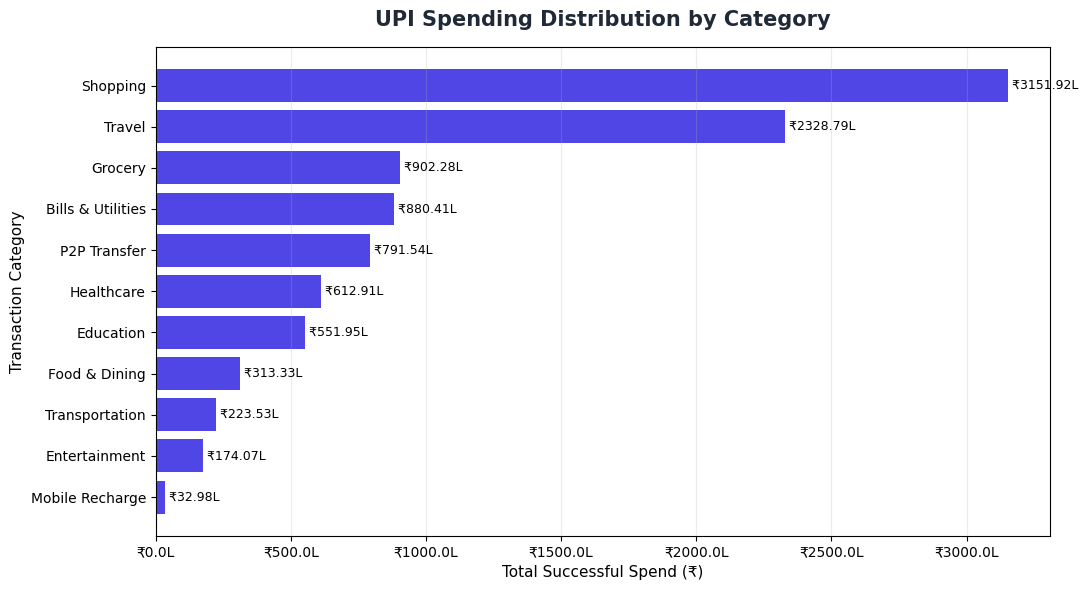

In [43]:
category_plot = category_spend.sort_values(
    "Total_Spend",
    ascending=True
)

plt.figure(figsize=(11, 6))

bars = plt.barh(
    category_plot.index,
    category_plot["Total_Spend"],
    color=COLORS["primary"]
)

plt.title(
    "UPI Spending Distribution by Category",
    fontweight="bold",
    color=COLORS["dark"],
    pad=15
)

plt.xlabel("Total Successful Spend (₹)")
plt.ylabel("Transaction Category")

# Add value labels
for bar in bars:
    value = bar.get_width()

    plt.text(
        value,
        bar.get_y() + bar.get_height()/2,
        f" ₹{value/100000:.2f}L",
        va="center",
        fontsize=9
    )

plt.gca().xaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, pos: f"₹{x/100000:.1f}L")
)

plt.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

# INSIGHT:
# This visualization identifies the categories contributing the highest transaction value. Categories with high total spend can be important for personalized budgeting recommendations and customer segmentation.

# **Visualization 2 - Monthly UPI Spending Trend**

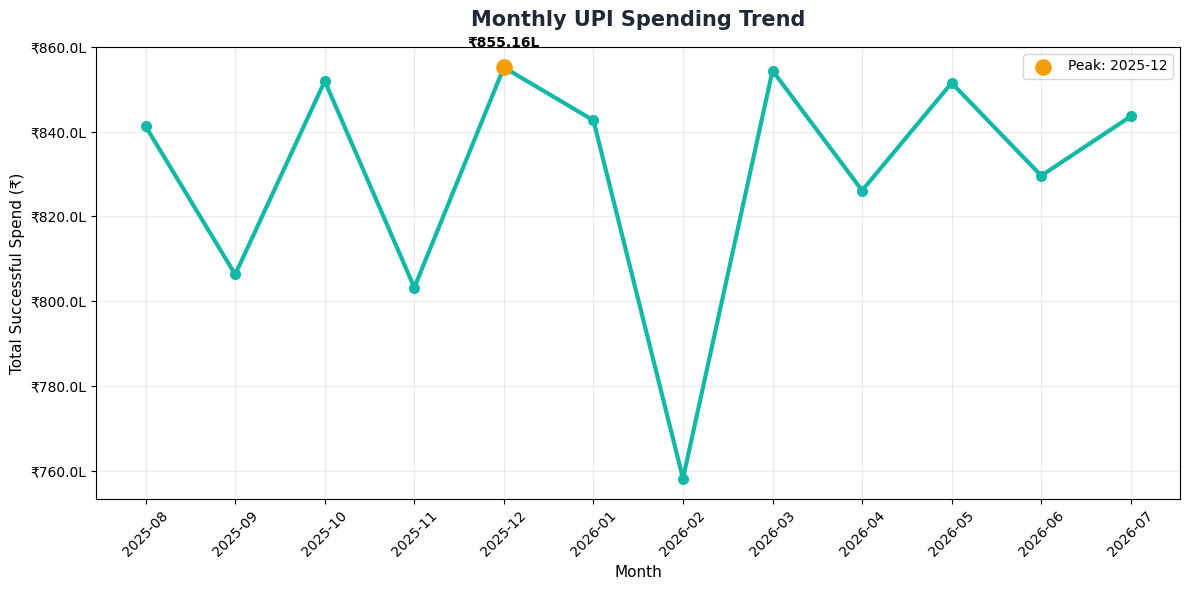

In [44]:
monthly_plot = (
    successful_txn
    .groupby(successful_txn["Transaction_Date"].dt.to_period("M"))["Amount"]
    .sum()
)

monthly_plot.index = monthly_plot.index.astype(str)

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_plot.index,
    monthly_plot.values,
    marker="o",
    linewidth=3,
    markersize=7,
    color=COLORS["secondary"]
)

# Highlight highest spending month
max_month = monthly_plot.idxmax()
max_value = monthly_plot.max()

plt.scatter(
    max_month,
    max_value,
    s=120,
    color=COLORS["accent"],
    zorder=3,
    label=f"Peak: {max_month}"
)

plt.annotate(
    f"₹{max_value/100000:.2f}L",
    xy=(max_month, max_value),
    xytext=(0, 15),
    textcoords="offset points",
    ha="center",
    fontweight="bold"
)

plt.title(
    "Monthly UPI Spending Trend",
    fontweight="bold",
    color=COLORS["dark"],
    pad=15
)

plt.xlabel("Month")
plt.ylabel("Total Successful Spend (₹)")

plt.xticks(rotation=45)

plt.gca().yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, pos: f"₹{x/100000:.1f}L")
)

plt.grid(alpha=0.25)
plt.legend()

plt.tight_layout()
plt.show()

# INSIGHT:
# The monthly trend helps identify periods of increased or decreased consumer spending. The highlighted peak month can be investigated further by category, user persona, and transaction behavior.

# **Visualization 3 - Persona-wise Average Transaction Value**

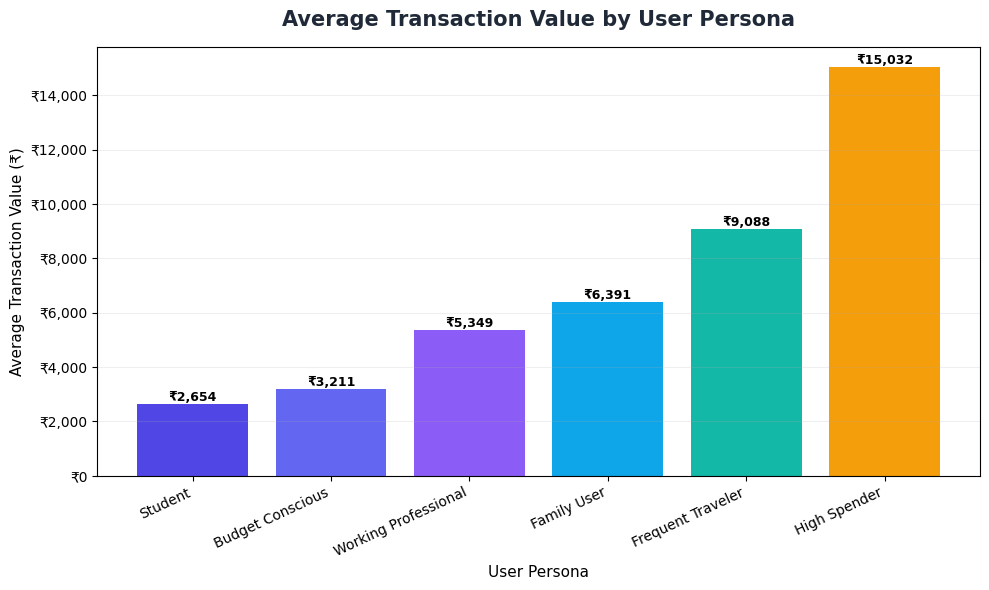

In [45]:
persona_avg = (
    successful_txn
    .groupby("User_Persona")["Amount"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(10, 6))

bars = plt.bar(
    persona_avg.index,
    persona_avg.values,
    color=[
        COLORS["primary"],
        "#6366F1",
        "#8B5CF6",
        "#0EA5E9",
        COLORS["secondary"],
        COLORS["accent"]
    ]
)

plt.title(
    "Average Transaction Value by User Persona",
    fontweight="bold",
    color=COLORS["dark"],
    pad=15
)

plt.xlabel("User Persona")
plt.ylabel("Average Transaction Value (₹)")

plt.xticks(rotation=25, ha="right")

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"₹{height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

plt.gca().yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, pos: f"₹{x:,.0f}")
)

plt.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

# INSIGHT:
# User personas demonstrate clearly different spending behaviors. This validates the persona-based synthetic data generation approach and provides a foundation for personalized financial insights and user-level anomaly detection.

# **Visualization 4 - Weekend vs Weekday Spending**

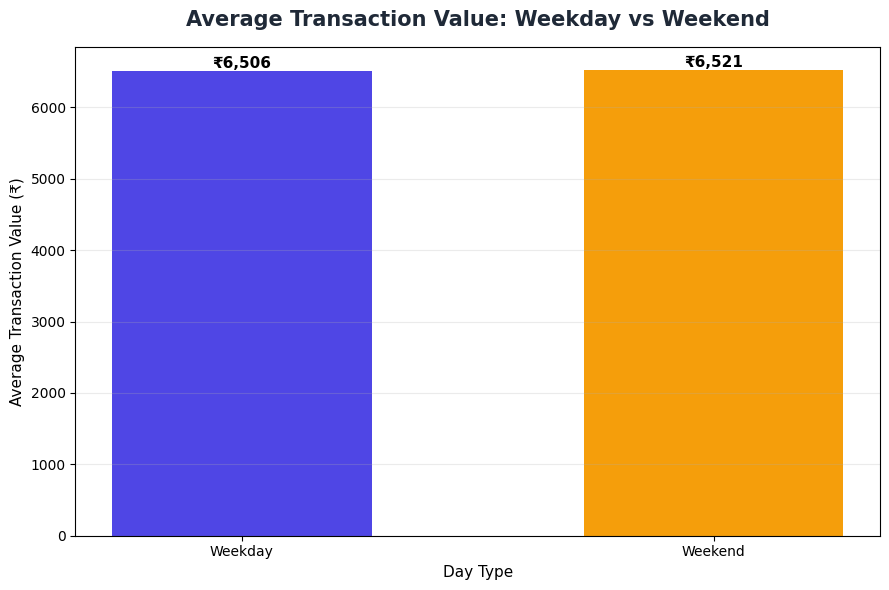

In [46]:
daytype_spend = (
    successful_txn
    .groupby("Day_Type")["Amount"]
    .agg(["sum", "mean", "count"])
)

# Proper order
daytype_spend = daytype_spend.reindex(
    ["Weekday", "Weekend"]
)

plt.figure(figsize=(9, 6))

bars = plt.bar(
    daytype_spend.index,
    daytype_spend["mean"],
    color=[COLORS["primary"], COLORS["accent"]],
    width=0.55
)

plt.title(
    "Average Transaction Value: Weekday vs Weekend",
    fontweight="bold",
    color=COLORS["dark"],
    pad=15
)

plt.xlabel("Day Type")
plt.ylabel("Average Transaction Value (₹)")

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"₹{height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

plt.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

# INSIGHT:
# Comparing weekday and weekend transaction values helps identify behavioral changes in consumer spending. A higher weekend average may indicate increased discretionary spending on categories such as dining, entertainment, and shopping.

# **Visualization 5 - Spending by Time Period**

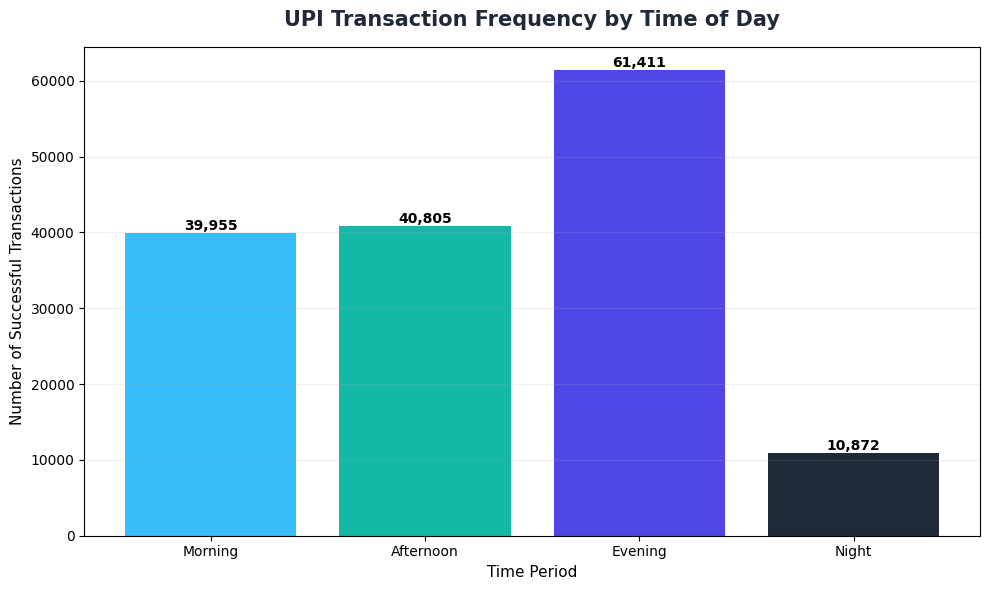

In [47]:
time_order = [
    "Morning",
    "Afternoon",
    "Evening",
    "Night"
]

time_spend = (
    successful_txn
    .groupby("Time_Period")["Amount"]
    .agg(["sum", "mean", "count"])
    .reindex(time_order)
)

plt.figure(figsize=(10, 6))

bars = plt.bar(
    time_spend.index,
    time_spend["count"],
    color=[
        "#38BDF8",
        COLORS["secondary"],
        COLORS["primary"],
        COLORS["dark"]
    ]
)

plt.title(
    "UPI Transaction Frequency by Time of Day",
    fontweight="bold",
    color=COLORS["dark"],
    pad=15
)

plt.xlabel("Time Period")
plt.ylabel("Number of Successful Transactions")

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

# INSIGHT:
# Transaction frequency varies across different times of the day. Time-based behavior can later be combined with transaction amount to identify unusual patterns, such as high-value late-night activity.

# **Visualization 6 - Transaction Volume vs Total Spend by Category**

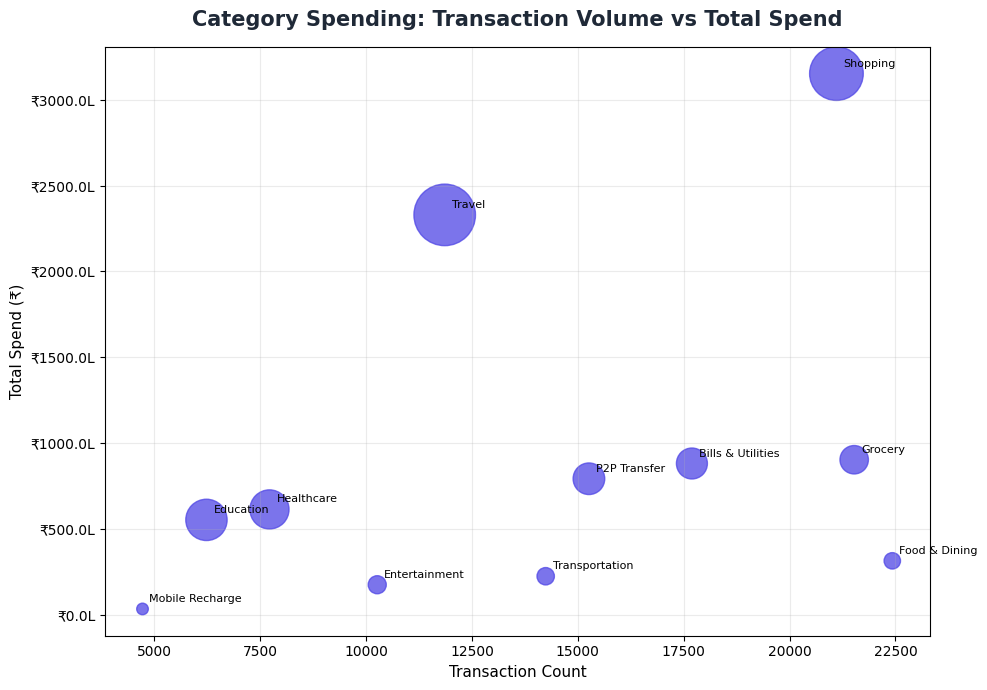

In [48]:
category_metrics = (
    successful_txn
    .groupby("Category")
    .agg(
        Transaction_Count=("Transaction_ID", "count"),
        Total_Spend=("Amount", "sum"),
        Avg_Transaction=("Amount", "mean")
    )
)

plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    category_metrics["Transaction_Count"],
    category_metrics["Total_Spend"],
    s=category_metrics["Avg_Transaction"] / 10,
    alpha=0.75,
    color=COLORS["primary"]
)

# Add category labels
for category, row in category_metrics.iterrows():
    plt.annotate(
        category,
        (
            row["Transaction_Count"],
            row["Total_Spend"]
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )

plt.title(
    "Category Spending: Transaction Volume vs Total Spend",
    fontweight="bold",
    color=COLORS["dark"],
    pad=15
)

plt.xlabel("Transaction Count")
plt.ylabel("Total Spend (₹)")

plt.gca().yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, pos: f"₹{x/100000:.1f}L")
)

plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

# INSIGHT:
# This analysis differentiates high-frequency categories from high-value categories. Categories appearing higher on the chart contribute more to overall spending, while larger bubbles represent categories with higher average transaction values.

# **Visualization 7 - Top 10 Merchants by Total Spend**

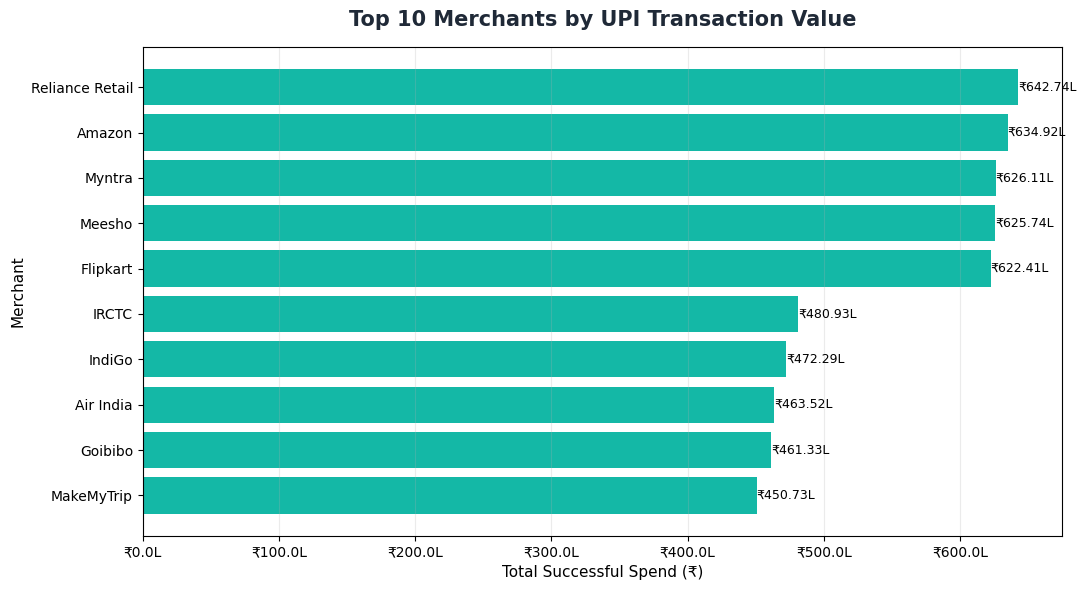

In [49]:
top_merchants = (
    successful_txn
    .groupby("Merchant")["Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

plt.figure(figsize=(11, 6))

bars = plt.barh(
    top_merchants.index,
    top_merchants.values,
    color=COLORS["secondary"]
)

plt.title(
    "Top 10 Merchants by UPI Transaction Value",
    fontweight="bold",
    color=COLORS["dark"],
    pad=15
)

plt.xlabel("Total Successful Spend (₹)")
plt.ylabel("Merchant")

for bar in bars:
    value = bar.get_width()

    plt.text(
        value,
        bar.get_y() + bar.get_height()/2,
        f"₹{value/100000:.2f}L",
        va="center",
        fontsize=9
    )

plt.gca().xaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, pos: f"₹{x/100000:.1f}L")
)

plt.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

# INSIGHT:
# The top merchant analysis identifies where users concentrate their spending. High-performing merchants can be important for partnership, cashback, reward, or personalized offer strategies.

# **Visualization 8 - Monthly Spend by User Persona**

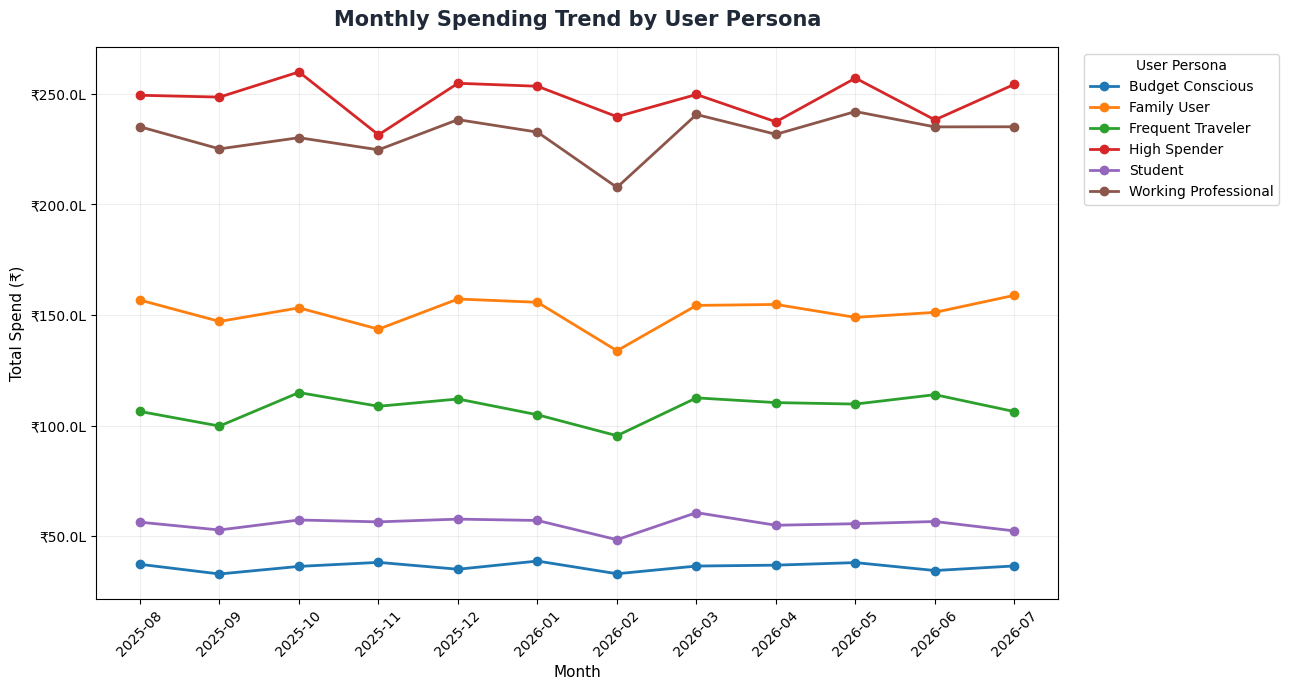

In [50]:
persona_monthly = successful_txn.copy()

persona_monthly["Month_Year"] = (
    persona_monthly["Transaction_Date"]
    .dt.to_period("M")
    .astype(str)
)

persona_monthly_summary = (
    persona_monthly
    .groupby(["Month_Year", "User_Persona"])["Amount"]
    .sum()
    .unstack()
)

plt.figure(figsize=(13, 7))

for persona in persona_monthly_summary.columns:

    plt.plot(
        persona_monthly_summary.index,
        persona_monthly_summary[persona],
        marker="o",
        linewidth=2,
        label=persona
    )

plt.title(
    "Monthly Spending Trend by User Persona",
    fontweight="bold",
    color=COLORS["dark"],
    pad=15
)

plt.xlabel("Month")
plt.ylabel("Total Spend (₹)")

plt.xticks(rotation=45)

plt.gca().yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, pos: f"₹{x/100000:.1f}L")
)

plt.legend(
    title="User Persona",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

# INSIGHT:
# Persona-level monthly trends reveal how different user segments contribute to spending over time. This segmentation can support targeted financial products, personalized recommendations, and more accurate user-level anomaly detection.